# 1. Persiapan Lingkungan dan Library

Pada tahap ini dilakukan pengecekan dan instalasi library yang dibutuhkan 
untuk analisis data sekuens biologis. Library utama yang digunakan adalah 
Biopython untuk pemrosesan data sekuens, serta Pandas dan NumPy untuk 
manipulasi data.

Langkah ini bertujuan untuk memastikan seluruh dependensi tersedia 
sehingga proses analisis dapat berjalan tanpa error.


In [1]:
try:
    import Bio  
    print("Biopython sudah terinstall.")
except ImportError:
    print("Sedang menginstall Biopython (perlu waktu sebentar)...")
    !pip install biopython -q  
    print("Instalasi selesai.")


import pandas as pd     
import numpy as np      
import re               
import os               
from Bio import SeqIO   
from IPython.display import display 


pd.set_option('display.max_colwidth', 50)


print("Lingkungan siap! Lanjut ke pembacaan data.")

Sedang menginstall Biopython (perlu waktu sebentar)...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/3.2 MB ? eta -:--:--

   ━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.3/3.2 MB 8.1 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 31.8 MB/s eta 0:00:00


Instalasi selesai.


Lingkungan siap! Lanjut ke pembacaan data.


# 2. Pembacaan dan Parsing Data Sekuens DNA

Tahap ini bertujuan untuk membaca dataset sekuens DNA dalam format FASTA 
menggunakan library Biopython. Proses parsing dilakukan untuk mengekstraksi 
Feature ID dan sekuens DNA dari setiap record.

Sekuens distandarisasi dalam huruf kapital untuk menjaga konsistensi 
dan mencegah perbedaan karakter selama tahap preprocessing dan ekstraksi fitur.

Data yang telah diparsing kemudian disimpan dalam bentuk DataFrame 
untuk memudahkan proses analisis lanjutan.

In [2]:

FILE_FASTA = '/kaggle/input/metagenom/0_dna-sequences-silva-v3-v4.fasta' 

print("Sedang membaca file FASTA...")

ids = []  
seqs = [] 

try:
    for record in SeqIO.parse(FILE_FASTA, "fasta"):
        ids.append(record.id)
        seqs.append(str(record.seq).upper()) 
    df_fasta = pd.DataFrame({
        'Feature ID': ids, 
        'Sequence': seqs
    })
    print(f"Berhasil memuat {len(df_fasta):,} sekuens DNA.")
    print("Data Sekuens Mentah:")
    display(df_fasta.head())

except FileNotFoundError:
    print("Error: File FASTA tidak ditemukan di path tersebut.")

Sedang membaca file FASTA...


Berhasil memuat 398,508 sekuens DNA.
Data Sekuens Mentah:


,Feature ID,Sequence
0,CP013078.2406498.2408039,TGGGGAATTTTGGACAATGGGGGCAACCCTGATCCAGCCATCCCGC...
1,CP015924.1224168.1225721,TGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCCATGCCGC...
2,CP003278.287486.289015,TGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCCATGCCGC...
3,LS483321.16842.18378,TAGGGAATCTTCGGCAATGGGGGCAACCCTGACCGAGCAACGCCGC...
4,CP012870.431955.433510,TGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCCATGCCGC...


# 3. Pembacaan Data Label Taksonomi

Tahap ini bertujuan untuk membaca file metadata taksonomi yang 
berisi label klasifikasi untuk setiap sekuens DNA.

File berformat TSV (Tab-Separated Values) dibaca menggunakan 
library Pandas untuk memastikan struktur tabel tetap terjaga.

Data label ini nantinya akan digunakan sebagai target variabel 
dalam proses pemodelan klasifikasi.

In [3]:

FILE_TSV = '/kaggle/input/metagenom/0_taxonomy.tsv'

print("Sedang membaca file Taksonomi...")

try:
    df_tsv = pd.read_csv(FILE_TSV, sep='\t')
    print(f"Berhasil memuat {len(df_tsv):,} label taksonomi.")
    print("Data Label Taksonomi:")
    display(df_tsv.head())

except FileNotFoundError:
    print("Error: File TSV tidak ditemukan.")

Sedang membaca file Taksonomi...


Berhasil memuat 436,680 label taksonomi.
Data Label Taksonomi:


,Feature ID,Taxon
0,CP013078.2406498.2408039,d__Bacteria; p__Proteobacteria; c__Gammaproteo...
1,CP015924.1224168.1225721,d__Bacteria; p__Proteobacteria; c__Gammaproteo...
2,CP003278.287486.289015,d__Bacteria; p__Proteobacteria; c__Gammaproteo...
3,LS483321.16842.18378,d__Bacteria; p__Firmicutes; c__Bacilli; o__Lac...
4,CP012870.431955.433510,d__Bacteria; p__Proteobacteria; c__Gammaproteo...


# 4. Integrasi Data Sekuens dan Label Taksonomi

Tahap ini bertujuan untuk menggabungkan data sekuens DNA dengan 
label taksonomi berdasarkan Feature ID sebagai primary key.

Proses integrasi dilakukan menggunakan metode inner join, 
sehingga hanya data yang memiliki pasangan ID pada kedua file 
yang akan dipertahankan.

Langkah ini penting untuk memastikan konsistensi antara 
fitur (sekuens DNA) dan target (label taksonomi) sebelum 
memasuki tahap preprocessing dan pemodelan.


In [4]:

print("Menggabungkan (Merge) Tabel Sekuens & Taksonomi...")

df_raw = pd.merge(
    df_fasta, 
    df_tsv, 
    on='Feature ID', 
    how='inner'
)

print(f"Integrasi selesai. Total data valid: {len(df_raw):,} sampel.")

print("Dataset Terintegrasi (Raw):")
display(df_raw.head())

Menggabungkan (Merge) Tabel Sekuens & Taksonomi...


Integrasi selesai. Total data valid: 398,508 sampel.
Dataset Terintegrasi (Raw):


,Feature ID,Sequence,Taxon
0,CP013078.2406498.2408039,TGGGGAATTTTGGACAATGGGGGCAACCCTGATCCAGCCATCCCGC...,d__Bacteria; p__Proteobacteria; c__Gammaproteo...
1,CP015924.1224168.1225721,TGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCCATGCCGC...,d__Bacteria; p__Proteobacteria; c__Gammaproteo...
2,CP003278.287486.289015,TGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCCATGCCGC...,d__Bacteria; p__Proteobacteria; c__Gammaproteo...
3,LS483321.16842.18378,TAGGGAATCTTCGGCAATGGGGGCAACCCTGACCGAGCAACGCCGC...,d__Bacteria; p__Firmicutes; c__Bacilli; o__Lac...
4,CP012870.431955.433510,TGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCCATGCCGC...,d__Bacteria; p__Proteobacteria; c__Gammaproteo...


# 5. Parsing Hierarki Taksonomi

Tahap ini bertujuan untuk memecah string taksonomi menjadi 
beberapa kolom terpisah berdasarkan tingkat hierarki biologis 
(Kingdom hingga Species).

Ekstraksi dilakukan menggunakan Regular Expression (regex) 
dengan pola khusus sesuai format database SILVA.

Proses ini memungkinkan analisis klasifikasi dilakukan pada 
level taksonomi tertentu, misalnya pada tingkat Phylum.

In [5]:

print("Memisahkan string taksonomi ke dalam kolom terpisah...")

df_parsed = df_raw.copy()

rank_map = {
    'Kingdom': 'd', 
    'Phylum': 'p',
    'Class': 'c',
    'Order': 'o',
    'Family': 'f',
    'Genus': 'g',
    'Species': 's'
}

for rank_name, code in rank_map.items():
    df_parsed[rank_name] = df_parsed['Taxon'].str.extract(f'{code}__([^;]+)')

df_parsed.drop(columns=['Taxon'], inplace=True)

print("Parsing hierarki selesai.")

print("Data dengan Hierarki Taksonomi Lengkap:")
display(df_parsed.head())

print("Struktur Kolom Baru:")
print(df_parsed.columns.tolist())

Memisahkan string taksonomi ke dalam kolom terpisah...


Parsing hierarki selesai.
Data dengan Hierarki Taksonomi Lengkap:


,Feature ID,Sequence,Kingdom,Phylum,Class,Order,Family,Genus,Species
0,CP013078.2406498.2408039,TGGGGAATTTTGGACAATGGGGGCAACCCTGATCCAGCCATCCCGC...,Bacteria,Proteobacteria,Gammaproteobacteria,Burkholderiales,Alcaligenaceae,Bordetella,Bordetella_pertussis
1,CP015924.1224168.1225721,TGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCCATGCCGC...,Bacteria,Proteobacteria,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Salmonella,Salmonella_enterica
2,CP003278.287486.289015,TGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCCATGCCGC...,Bacteria,Proteobacteria,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Salmonella,Salmonella_enterica
3,LS483321.16842.18378,TAGGGAATCTTCGGCAATGGGGGCAACCCTGACCGAGCAACGCCGC...,Bacteria,Firmicutes,Bacilli,Lactobacillales,Streptococcaceae,Streptococcus,Streptococcus_pyogenes
4,CP012870.431955.433510,TGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCCATGCCGC...,Bacteria,Proteobacteria,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Escherichia-Shigella,Escherichia_coli


Struktur Kolom Baru:
['Feature ID', 'Sequence', 'Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']


# 6. Seleksi Target Klasifikasi Tingkat Phylum

Pada tahap ini dilakukan pemilihan level taksonomi yang akan 
digunakan sebagai target klasifikasi, yaitu tingkat Phylum.

Dataset difokuskan pada tiga kolom utama:
- Feature ID sebagai identifier unik,
- Sequence sebagai fitur utama (input model),
- Phylum sebagai target variabel (label).

In [6]:

print("Menyeleksi kolom untuk analisis tingkat Phylum...")

df_phylum = df_parsed[['Feature ID', 'Sequence', 'Phylum']].copy()

print(f"Dataframe final untuk tingkat Phylum terbentuk.")
print(f"  - Jumlah Sampel : {len(df_phylum):,}")
print(f"  - Jumlah Kolom  : {len(df_phylum.columns)} (ID, Sequence, Phylum)")

print("Dataset Final (Phylum):")
display(df_phylum.head())

print("Informasi Dataset:")
df_phylum.info()

Menyeleksi kolom untuk analisis tingkat Phylum...
Dataframe final untuk tingkat Phylum terbentuk.
  - Jumlah Sampel : 398,508
  - Jumlah Kolom  : 3 (ID, Sequence, Phylum)
Dataset Final (Phylum):


,Feature ID,Sequence,Phylum
0,CP013078.2406498.2408039,TGGGGAATTTTGGACAATGGGGGCAACCCTGATCCAGCCATCCCGC...,Proteobacteria
1,CP015924.1224168.1225721,TGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCCATGCCGC...,Proteobacteria
2,CP003278.287486.289015,TGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCCATGCCGC...,Proteobacteria
3,LS483321.16842.18378,TAGGGAATCTTCGGCAATGGGGGCAACCCTGACCGAGCAACGCCGC...,Firmicutes
4,CP012870.431955.433510,TGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCCATGCCGC...,Proteobacteria


Informasi Dataset:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398508 entries, 0 to 398507
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Feature ID  398508 non-null  object
 1   Sequence    398508 non-null  object
 2   Phylum      398508 non-null  object
dtypes: object(3)
memory usage: 9.1+ MB


# 7. Audit dan Validasi Kualitas Sekuens DNA

Setelah dataset difokuskan pada tingkat klasifikasi **Phylum** dan kolom yang relevan (Feature ID, Sequence, dan Phylum) telah diseleksi, tahap selanjutnya adalah melakukan audit kualitas data sekuens.

Audit ini bertujuan untuk memastikan bahwa seluruh sekuens DNA berada dalam kondisi yang layak untuk diproses lebih lanjut pada tahap ekstraksi fitur dan pemodelan machine learning.

Tahapan audit yang dilakukan meliputi:

1. **Analisis Statistik Panjang Sekuens**  
   Menghitung nilai minimum, maksimum, rata-rata, dan median panjang sekuens untuk memahami karakteristik distribusi data.

2. **Distribusi Rentang Panjang Sekuens**  
   Mengelompokkan panjang sekuens ke dalam beberapa interval guna melihat persebaran jumlah bakteri berdasarkan ukuran fragmen DNA.

3. **Audit Karakter Non-Standar (Noise) Secara Global**  
   Mengidentifikasi keberadaan karakter selain basa standar DNA (A, T, G, C) untuk mengukur tingkat kontaminasi pada keseluruhan dataset.

4. **Audit Tingkat Sampel**  
   Menghitung jumlah karakter non-standar pada setiap sekuens guna mengetahui apakah terdapat sampel dengan tingkat noise yang signifikan.

5. **Validasi Proses Cleaning**  
   Membandingkan distribusi karakter sebelum dan sesudah proses pembersihan untuk memastikan bahwa data akhir hanya mengandung basa DNA standar.


MEMULAI AUDIT & VISUALISASI...



[1] STATISTIK PANJANG SEKUENS:
    - Minimum       : 51 bp
    - Maksimum      : 464 bp
    - Rata-rata     : 416.31 bp
    - Median        : 422 bp

[1.1] RINCIAN PERSEBARAN BAKTERI PER RENTANG PANJANG:


,Rentang Panjang,Jumlah Bakteri,Persentase (%)
0,< 100 bp,20,0.0050%
1,100 - 200 bp,97,0.0243%
2,200 - 300 bp,467,0.1172%
3,300 - 400 bp,22141,5.5560%
4,400 - 500 bp,375783,94.2975%
5,> 500 bp,0,0.0000%


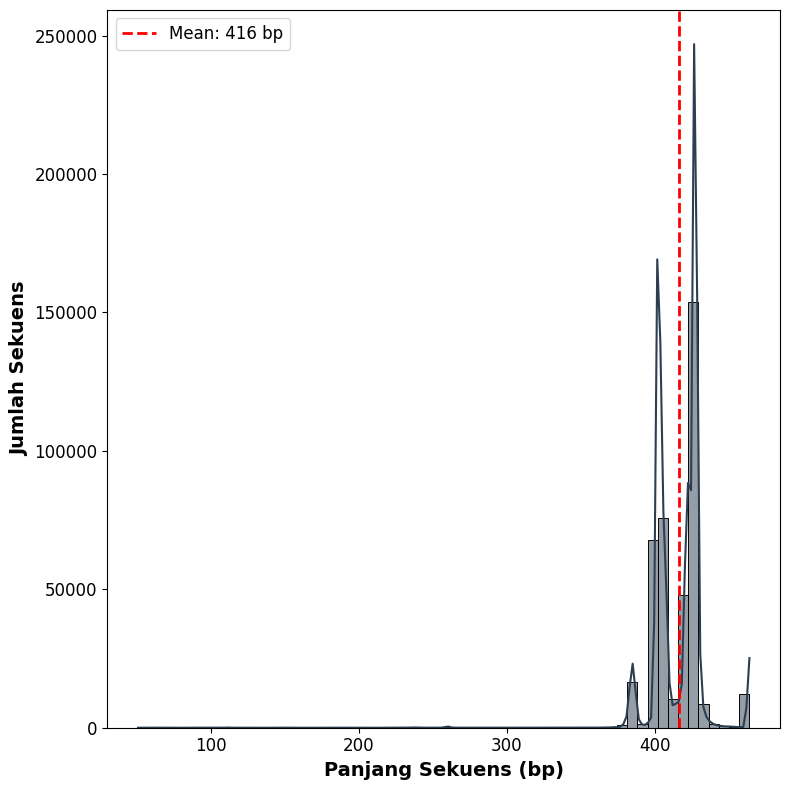


[2] AUDIT KONTAMINAN GLOBAL (Apa saja noise-nya?):
    - Total Karakter Data : 165,901,789 bp
    - Total Karakter Noise: 17,824 bp (0.01074% dari total)

    >>> Rincian Jenis Noise:


,Karakter,Jumlah
2,N,12452
1,R,1605
4,Y,1128
6,S,996
0,K,679
3,W,452
7,M,425
5,H,27
9,V,21
8,B,20


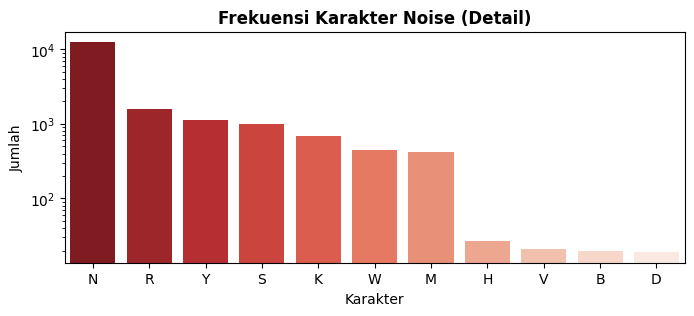


[3] AUDIT TINGKAT SAMPEL (Bakteri mana yang bermasalah?):


    Ditemukan 12,438 bakteri yang mengandung noise (3.12% dari populasi).
    - Noise Terbanyak di satu bakteri : 4 karakter
    - Rata-rata Noise (pada data kotor): 1.4 karakter

    >>> Tabel 10 Bakteri dengan Noise Terbanyak:


,Feature ID,Phylum,Noise_Count,Sequence
277597,JQ427442.1.1516,Firmicutes,4,TAGGGAATCTTCCGCAATGGACGAAAGTCTGACGGAGCAACGCCGCGTGAGTGAGGAAGGCCTTCGGGTCGTAAAACTCTGTTGTTAGGGAAGAACACGTGCCGTTCGAATAGGGCGGCATCTTGACGGTACCTAACCAGAAAGCCACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTGGCAAGCGTTGTCCGGAATTATTGGGCGTAAAGCGCGCGCAGGCGGTTCCTTAAGTCTGATGTGAAAGCCCACGGCTCAACCGTGGAGGGTCATTGGAAACTGGGGAACTTGAAGACAGAAGAGGAGAGCGGAATTCCACGTGTAGCTAGCGTGAATGCGTANAGATNNGAGGACNCCAGTGGCGAAGGCGGCTCTCTGGTCTGTGCTTGACGCTGAGGCGCGAAAGCGTGGGGAGCGAACA
277179,JQ425902.1.1493,Proteobacteria,4,TGGGGAATATTGGACAATGGGGGCAACCCTGATCCAGCGACGCCGCGTGTGTGAAGAAGGCCTGCGGGTTGTAAAGCACTTNTAGTGGGGATGAAAAGCTCAGGGCTAATACCTCTGGGTCTTGACCTAACCCACAGAAAAAGCACCGGCTAACTCTGTGCCAGCAGCCGCGGTAATACAGAGGGTGCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGACGGTTACATAAGTCGGGTGTGAAAGCCCCGGGCTCAACCTGGGAATTGCATTCGAGACTGCGTAGCTAGGGTGCGGAAGANGGAAGCGGAATTTCGGGTGTAGCGGTGAAATGCGTAGATATCCGAAGGAACATCAGTGGCGAAAGCGGCTTCCTGGTCCAGCACCGACGTTCAGNNACGAAAGCGTGGGGAGCAAACA
278493,JQ448737.1.1375,Proteobacteria,4,TGGGGAATATTGCGCAATGGGGGGAACCCTGACGCAGCCATGCCGCGTGAATGAAGAAGGCCTTCGGGTTGTAAAGTTCTTTCGGTATTGAGGAAGGGATGTGTGCTAATATACATATCATTGACTTAAATACAGAGGAACACCNGGCTAACTCCGTGCCAGCAGCCGCGGTATACGGAGGTGCGAGCTTAATCGGATAACTGGGCGTAAAGGGCACGCAGGCGGGTATTTAAGTGAGGTGTGAAAGCCCCGGGCTNNAACCTAGGAANTGCATTTCAGGCTGGGTAACTAGAGTACTTTAGGGAGGGGTAGAATTCCACGTGTAGCGGTGAAATGCGTAGAGATGTGGAGGAATACCGAAGGCGAAGGCAGCCCCTTGGGAATGTACTGACGCTCATGTGCGAAAGCGTGGGGAGCAAACA
42535,AJ870309.1.910,Crenarchaeota,4,GCGAGAAAACTTTGCAATGTGCGAAAGCACGACAAGGTTAATCCGAGTGGTTTCTGCTAAAGGAACCTTTTGTTAGTTCTAGAAACACTAACGAATAAGGGGTGGGCAAGTTCTGGTGTCAGCCGCCGCGGTAAAACAGCACCTCAAGTGGTCAGGATGATTATTGGGCCTAAAGCATCCGTAGCCGGCTCTGTAAGTTTTCGGTTAAATCTGTACGCTCAACGTACAGGCTGCCGGGAATACTGCANANCTAGGGAGTGGGAGAGGTAGACGGTACTCGGNAGGAAGTGGTAAAATNCTTTGATCTATGGATGACCACCTGTGGCGAAGGCGGTCTACCAGAACACGTCCGACGGTGAGGGATGAAAGCTGGGGGAGCAAACC
268889,JN896865.1.1380,Gemmatimonadota,4,TGGGGAATATTGCGCAATGGATGAAAGTCTGACGCAGCGACGCCGCGTGTGGGATGAAGCTCTTCGGGGTGTAAACCACTGTTGCCCGGGACGAATATCCTTCTTTAGAAGGATTGACGGTACCGGGTGAGGAAGCACCGGCTAACTCTGTGCCAGCAGCCGCGGTAATACAGAGGGTGCGAGCGTTGTCCGGAATCACTGGGCGTAANGGGCGCGNAGGTGGCTCGTTANNCGTGTGGTGAAAGCCTGGGGCTCAACCCCAGGTCTGCCGTGCGAACTGGCGAGCTTGAGAGTAGTAGAGGCGGGTGGAATTTCGGGTGTAGCGGTGGAATGCGTAGATATCCGAAAGAACACCGGTGGCGAAGGCGGCCCGCTGGGCTATTTCTGACACTGATGCGCGACAGCGTGGGGAGCAAACA
143711,FJ192258.1.1455,Proteobacteria,4,TGGGGGAATATTGGACAATGGGCGCAAGCCTGATCCAGCCATGCCGCGTGGGTGAAGAAGGCCTTTTGGTTGTAAAGCACTTTTAGCGAGGAAGAGGCTACCTGGGATTAGTACTCTGGGGATAGTGGGACGTTACTCGCAGAATAAGCACCGGGCTAAACTCTGTGCCAGCAGCCCGCGGGTAATACAGAGGGGTGCGAGCGTTAATCGGATTTACTGGGCGTAAAGCGTGCGTAGGCGGCTTTTTAAGTCGGATGTGAAATCCCTGAGCTTAACTTAGGAATTGCATTCGATACTGGGAAGCTAGAGTATGGGAGAGGATGGTAGAATTCCAGGTGTAGCGGTGAAATGCGTAGAGATCTGGAGAATACGATGGCGANNGCAGCCATCTGGCNNATACTGACGCTGAGGTACGAAAGCATGGGGAGCAAACA
133539,EU767154.1.1360,Bacteroidota,4,TGAGGAATATTGGTCAATGGGCGATGGCCTGAACCAGCCAAGTAGCGTGAAGGATGACTGCCCTATGGGTTGGTAACTTTCTTTATAAAGGAATAAAGTCGGGTATGCACACCCGTTTGCATGTACTTTATGAATAAAGATCGGCTAACTCCCGTGCAGCAGCTGCGGTAATACGGAGGATCCGAGCGTTANNCCGGATTATTGNNGTTAAGGGAGCGTAGATGGATGTTTAAGTCAGCTGTGAAAGTTTGCGGCTCAACCGTAAAATGCCAGTTGATACTGGATGTCTTGAGTGCATTGAGGCAGGCGGAATTCGTGGTGTAGCGGTGAAATGCTTAGATATCACGAAGAACTCCGATTGCGAAGGCAGCCTGCTAAGCTGCAACTGACATTGAGGCTCGAAAGTGTGGGTATCAAACA
131054,EU652665.1.1507,Nitrospirota,4,TGAGGAATATTGCGCAATGGGCGAAAGCCTGACGCAGCGACGCCGCGTGGGGGATGAAGGTTCTCGGATTGTAAACCMCYTTCATGAGGAAAGAATAAAGTGGGTAACCACCTTAGACCGGTACCTCMAGAAGAAGCCACGGCTAMCTTTGTGCCAGCAGCCGCGGTAATACGAAGGTGGCGAGCGTTGTTCGGATTTACTGGGCGTAAAGAGCACGTAGGCCGGTTAGGTAAGCCTCTTGGGAAAGCTTCCGGCTCAACCCGGGAAAGATCGGGGGGAACTACTTTAGCTAGAGGACGGGAGAGGAGCGCGGAATTCCCCGGTGTAGCGGTGAAATGCGTAGATATCGGGAAGAAGGCCGGTAGCGAAGGCGGCGCTCTGGAACGTACCTGACGCTGAGGTGCGAAAGCGTGGGGAGCAAACA
131053,EU652663.1.1511,Nitrospirota,4,TGAGGAATATTGCGCAATGGGCGAAAGCCTGACGCAGCGACGCCGCGTGGGGGATGAAGGTTKKCGGGAWTGTCAAMCCCTCTTTTTTGTGAGGAAAGAGAGAAAGGTGGGTAACCACTTAGACGGTACCTCAAGAAAAAGCCACGGCTAACTTCGTGCCAGCAGCCGCGGTAATACGAAAGGTGGCGAGCGTTGTTCGGATTTACTGGGCGTAAAGAGCACGTAGGCGGTTGGGTAAGCCTCTTG


TAHAP 4: VISUALISASI PERBANDINGAN (SEBELUM vs SESUDAH PEMBERSIHAN)


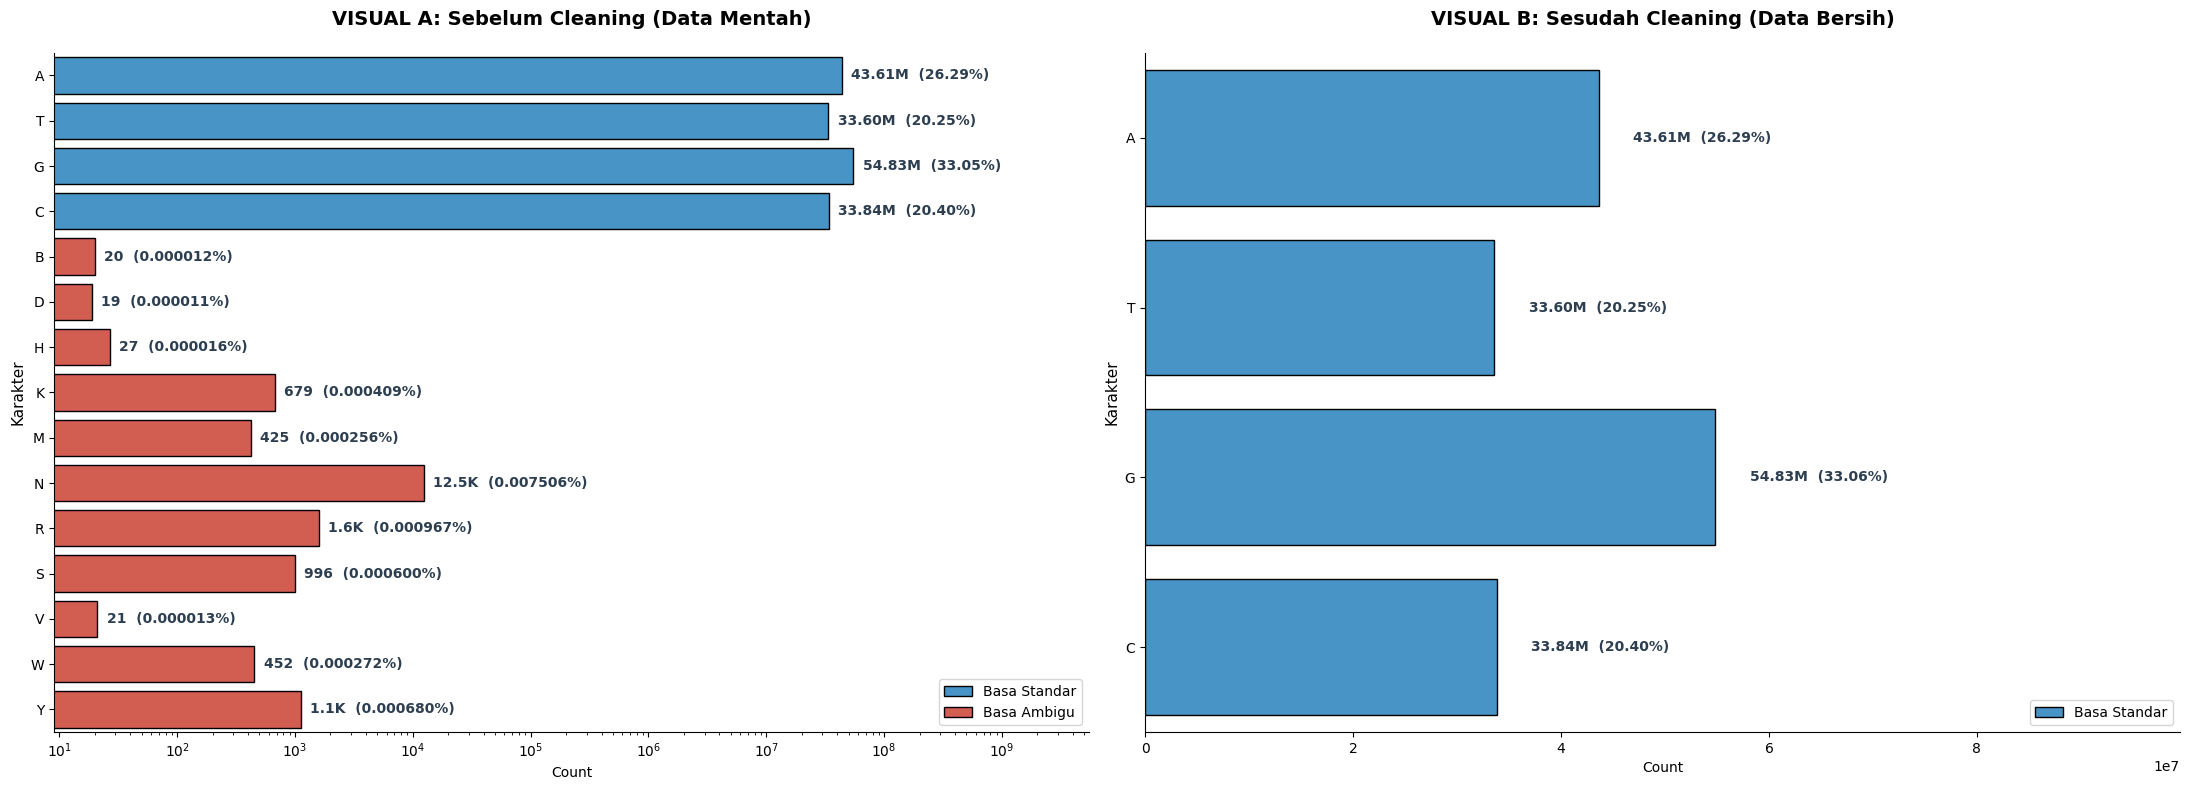

In [7]:

from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("MEMULAI AUDIT & VISUALISASI...")


df_audit = df_phylum.copy()

lengths = df_audit['Sequence'].str.len()


print(f"\n[1] STATISTIK PANJANG SEKUENS:")
print(f"    - Minimum       : {lengths.min()} bp")
print(f"    - Maksimum      : {lengths.max()} bp")
print(f"    - Rata-rata     : {lengths.mean():.2f} bp")
print(f"    - Median        : {lengths.median():.0f} bp")


print(f"\n[1.1] RINCIAN PERSEBARAN BAKTERI PER RENTANG PANJANG:")

bins = [0, 100, 200, 300, 400, 500, float('inf')]
labels = ['< 100 bp', '100 - 200 bp', '200 - 300 bp',
          '300 - 400 bp', '400 - 500 bp', '> 500 bp']

spread_analysis = pd.cut(lengths, bins=bins, labels=labels) \
                    .value_counts() \
                    .sort_index()

df_spread = pd.DataFrame({
    'Rentang Panjang': spread_analysis.index,
    'Jumlah Bakteri': spread_analysis.values,
    'Persentase (%)': (spread_analysis.values / len(df_audit) * 100)
})

display(df_spread.style.format({'Persentase (%)': '{:.4f}%'})
                    .background_gradient(cmap='Blues'))



plt.figure(figsize=(8, 8))

sns.histplot(
    lengths,
    bins=60,
    kde=True,
    color='#2c3e50'
)

plt.axvline(
    lengths.mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean: {lengths.mean():.0f} bp'
)

plt.xlabel('Panjang Sekuens (bp)', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Sekuens', fontsize=14, fontweight='bold')

plt.title('')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


print("\n[2] AUDIT KONTAMINAN GLOBAL (Apa saja noise-nya?):")

all_text = "".join(df_audit['Sequence'])

all_counter = Counter(all_text)

noise_dict = {k: v for k, v in all_counter.items() if k not in 'ATGC'}

total_noise = sum(noise_dict.values())
total_chars = len(all_text)

print(f"    - Total Karakter Data : {total_chars:,} bp")
print(f"    - Total Karakter Noise: {total_noise:,} bp ({total_noise/total_chars:.5%} dari total)")

if total_noise > 0:
    df_noise_char = pd.DataFrame(list(noise_dict.items()), columns=['Karakter', 'Jumlah'])
    df_noise_char = df_noise_char.sort_values('Jumlah', ascending=False)

    print("\n    >>> Rincian Jenis Noise:")
    display(df_noise_char.style.background_gradient(cmap='Reds'))

    plt.figure(figsize=(8, 3))
    sns.barplot(data=df_noise_char,
                x='Karakter',
                y='Jumlah',
                hue='Karakter',
                palette='Reds_r',
                legend=False)

    plt.title('Frekuensi Karakter Noise (Detail)', fontweight='bold')
    plt.yscale('log')
    plt.show()
else:
    print("    CLEAN: Tidak ditemukan noise sama sekali.")


print("\n[3] AUDIT TINGKAT SAMPEL (Bakteri mana yang bermasalah?):")

df_audit['Noise_Count'] = df_audit['Sequence'].str.count(r'[^ATGC]')

df_dirty = df_audit[df_audit['Noise_Count'] > 0] \
           .sort_values('Noise_Count', ascending=False)

n_dirty = len(df_dirty)
n_total = len(df_audit)

if n_dirty > 0:
    print(f"    Ditemukan {n_dirty:,} bakteri yang mengandung noise ({n_dirty/n_total:.2%} dari populasi).")
    print(f"    - Noise Terbanyak di satu bakteri : {df_dirty['Noise_Count'].max()} karakter")
    print(f"    - Rata-rata Noise (pada data kotor): {df_dirty['Noise_Count'].mean():.1f} karakter")

    print("\n    >>> Tabel 10 Bakteri dengan Noise Terbanyak:")
    top_dirty = df_dirty[['Feature ID', 'Phylum', 'Noise_Count', 'Sequence']].head(10)
    display(top_dirty.style.background_gradient(subset=['Noise_Count'], cmap='Reds'))
else:
    print("AMAN: Tidak ada satu pun sampel bakteri yang mengandung noise.")


print("\n" + "="*60)
print("TAHAP 4: VISUALISASI PERBANDINGAN (SEBELUM vs SESUDAH PEMBERSIHAN)")
print("="*60)

all_text_raw = all_text
counter_before = all_counter
total_before = total_chars

df_clean = df_audit.copy()
df_clean['Sequence'] = df_clean['Sequence'].str.replace(r'[^ATGC]', '', regex=True)

all_text_clean = "".join(df_clean['Sequence'])
counter_after = Counter(all_text_clean)
total_after = sum(counter_after.values())


def plot_dna_high_precision(counter_data, total_count, ax, title, is_log=False):

    valid_chars = ['A', 'T', 'G', 'C']
    noise_chars = sorted([k for k in counter_data.keys() if k not in valid_chars])
    sorted_chars = valid_chars + noise_chars

    data_list = []
    for char in sorted_chars:
        count = counter_data.get(char, 0)
        if count > 0:
            pct = (count / total_count) * 100
            Type = 'Basa Standar' if char in valid_chars else 'Basa Ambigu'
            data_list.append({'Char': char, 'Count': count, 'Pct': pct, 'Type': Type})

    df_viz = pd.DataFrame(data_list)

    colors = {'Basa Standar': '#3498db', 'Basa Ambigu': '#e74c3c'}

    sns.barplot(data=df_viz,
                x='Count',
                y='Char',
                hue='Type',
                palette=colors,
                ax=ax,
                dodge=False,
                edgecolor='black')

    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            count_val = int(width)
            pct_val = (count_val / total_count) * 100

            if count_val >= 1_000_000:
                str_count = f"{count_val/1e6:.2f}M"
            elif count_val >= 1_000:
                str_count = f"{count_val/1e3:.1f}K"
            else:
                str_count = f"{count_val}"

            if pct_val < 0.01:
                str_pct = f"({pct_val:.6f}%)"
            else:
                str_pct = f"({pct_val:.2f}%)"

            final_label = f"{str_count}  {str_pct}"

            x_pos = width * 1.2 if is_log else width + (total_count * 0.02)

            ax.text(x_pos,
                    p.get_y() + p.get_height()/2,
                    final_label,
                    ha='left',
                    va='center',
                    fontsize=10,
                    fontweight='bold',
                    color='#2c3e50')

    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_ylabel('Karakter', fontsize=11)

    if is_log:
        ax.set_xscale('log')
        ax.set_xlim(right=df_viz['Count'].max() * 100)
    else:
        ax.set_xlim(right=total_count * 0.6)

    sns.despine(ax=ax)
    ax.legend(loc='lower right', title=None)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

plot_dna_high_precision(counter_before, total_before, ax1,
                        "VISUAL A: Sebelum Cleaning (Data Mentah)",
                        is_log=True)

plot_dna_high_precision(counter_after, total_after, ax2,
                        "VISUAL B: Sesudah Cleaning (Data Bersih)",
                        is_log=False)

plt.tight_layout()
plt.show()

# 8. Pembersihan (Cleaning) Sekuens DNA

Pada tahap ini dilakukan pembersihan karakter non-standar selain basa DNA (A, T, G, C). 
Setelah proses penghapusan noise, dilakukan pengecekan ulang untuk memastikan tidak ada 
sekuens yang menjadi kosong. Dataset akhir yang dihasilkan merupakan data bersih 
yang siap digunakan pada tahap ekstraksi fitur.

In [8]:

import re

print("MENJALANKAN PEMBERSIHAN...")

df_clean = df_phylum.copy()
n_awal = len(df_clean)


print("   -> Langkah 1: Menghapus karakter noise...")

df_clean['Sequence_Clean'] = df_clean['Sequence'].apply(
    lambda x: re.sub(r'[^ATGC]', '', x)
)


print("   -> Langkah 2: Mengecek sekuens kosong pasca-pembersihan...")

df_clean['Len_Check'] = df_clean['Sequence_Clean'].str.len()
empty_seqs = df_clean[df_clean['Len_Check'] == 0]

if len(empty_seqs) > 0:
    print(f"      Ditemukan {len(empty_seqs)} sekuens menjadi KOSONG.")
    print("      Tindakan: Menghapus sampel tersebut dari dataset.")
    df_clean = df_clean[df_clean['Len_Check'] > 0]
else:
    print("      Aman. Tidak ada sekuens yang menjadi kosong.")


df_clean['Sequence'] = df_clean['Sequence_Clean']
df_clean.drop(columns=['Sequence_Clean', 'Len_Check'], inplace=True)

n_akhir = len(df_clean)

print("\nEKSEKUSI SELESAI.")
print(f"   - Sampel Dibuang : {n_awal - n_akhir} sampel")
print(f"   - Total Sampel Akhir : {n_akhir:,} sampel")


MENJALANKAN PEMBERSIHAN...
   -> Langkah 1: Menghapus karakter noise...


   -> Langkah 2: Mengecek sekuens kosong pasca-pembersihan...
      Aman. Tidak ada sekuens yang menjadi kosong.



EKSEKUSI SELESAI.
   - Sampel Dibuang : 0 sampel
   - Total Sampel Akhir : 398,508 sampel


# 9. Analisis Ketidakseimbangan Kelas (Class Imbalance)

Pada tahap ini dilakukan analisis distribusi kelas Phylum untuk 
mengetahui tingkat ketidakseimbangan antar kelas. 

In [9]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("MEMERIKSA KESEIMBANGAN KELAS PHYLUM...")

df_imbalance = df_clean.copy()


class_counts = df_imbalance['Phylum'].value_counts()
n_classes = len(class_counts)
total_samples = len(df_imbalance)

majority_lbl = class_counts.index[0]
majority_val = class_counts.iloc[0]

minority_lbl = class_counts.index[-1]
minority_val = class_counts.iloc[-1]

ratio = majority_val / minority_val

print(f"\n[1] STATISTIK DISTRIBUSI KELAS:")
print(f"   - Total Kelas Unik   : {n_classes} Phylum")
print(f"   - Kelas Mayoritas    : {majority_lbl} ({majority_val:,} sampel)")
print(f"   - Kelas Minoritas    : {minority_lbl} ({minority_val:,} sampel)")
print(f"   - Rasio Ketimpangan  : 1 : {ratio:.0f} (Sangat Timpang!)")


THRESHOLD = 3 

target_minority = class_counts[class_counts <= THRESHOLD]
target_labels = target_minority.index.tolist()

print(f"\n[2] IDENTIFIKASI TARGET REGROUPING (Threshold <= {THRESHOLD}):")

if len(target_labels) > 0:
    print(f"   Ditemukan {len(target_labels)} Phylum minoritas ekstrem.")
    print(f"   Total sampel yang akan digabung ke 'Others': {target_minority.sum()} sampel.")
    print("\n   [TABEL DISTRIBUSI AWAL - Top 5 & Bottom 5]:")

    top5 = class_counts.head(5).reset_index()
    top5.columns = ['Phylum', 'Jumlah']
    top5['Status'] = 'Mayoritas (Top 5)'
    bot5 = class_counts.tail(5).reset_index()
    bot5.columns = ['Phylum', 'Jumlah']
    bot5['Status'] = 'Minoritas (Bottom 5)'
    display(
        pd.concat([top5, bot5], ignore_index=True)
        .style.background_gradient(subset='Jumlah', cmap='Blues')
    )

else:
    print("   Data relatif seimbang (tidak ada kelas di bawah threshold).")

MEMERIKSA KESEIMBANGAN KELAS PHYLUM...



[1] STATISTIK DISTRIBUSI KELAS:
   - Total Kelas Unik   : 198 Phylum
   - Kelas Mayoritas    : Proteobacteria (106,470 sampel)
   - Kelas Minoritas    : Animalia (1 sampel)
   - Rasio Ketimpangan  : 1 : 106470 (Sangat Timpang!)

[2] IDENTIFIKASI TARGET REGROUPING (Threshold <= 3):
   Ditemukan 29 Phylum minoritas ekstrem.
   Total sampel yang akan digabung ke 'Others': 59 sampel.

   [TABEL DISTRIBUSI AWAL - Top 5 & Bottom 5]:


,Phylum,Jumlah,Status
0,Proteobacteria,106470,Mayoritas (Top 5)
1,Firmicutes,100595,Mayoritas (Top 5)
2,Bacteroidota,43912,Mayoritas (Top 5)
3,Actinobacteriota,35165,Mayoritas (Top 5)
4,Cyanobacteria,9134,Mayoritas (Top 5)
5,MAST-24,1,Minoritas (Bottom 5)
6,Pavlovophyceae,1,Minoritas (Bottom 5)
7,Picozoa,1,Minoritas (Bottom 5)
8,Alveolata,1,Minoritas (Bottom 5)
9,Animalia,1,Minoritas (Bottom 5)


# 10. Regrouping Kelas Minoritas dan Finalisasi Dataset

Pada tahap ini dilakukan penggabungan kelas Phylum minoritas ekstrem 
ke dalam kategori "Others" untuk mengurangi ketidakseimbangan kelas. 


EKSEKUSI REGROUPING & VISUALISASI FINAL...



[1] LAPORAN PERUBAHAN STRUKTUR DATA:
   - Total Kelas Awal       : 198 Phylum
   - Total Kelas Akhir      : 170 Phylum
   - Pengurangan Kelas      : 28 kelas
   - Total Sampel 'Others'  : 59 sampel

[2] TABEL DISTRIBUSI FINAL:


,Phylum,Jumlah,Kategori
0,Proteobacteria,106470,TOP 5 (Dominan)
1,Firmicutes,100595,TOP 5 (Dominan)
2,Bacteroidota,43912,TOP 5 (Dominan)
3,Actinobacteriota,35165,TOP 5 (Dominan)
4,Cyanobacteria,9134,TOP 5 (Dominan)
5,MAST-2,5,BOTTOM 5 (Terkecil)
6,Fervidibacteria,4,BOTTOM 5 (Terkecil)
7,Opalinata,4,BOTTOM 5 (Terkecil)
8,10bav-F6,4,BOTTOM 5 (Terkecil)
9,Firestonebacteria,4,BOTTOM 5 (Terkecil)



[VISUALISASI] DISTRIBUSI PHYLUM (FINAL)


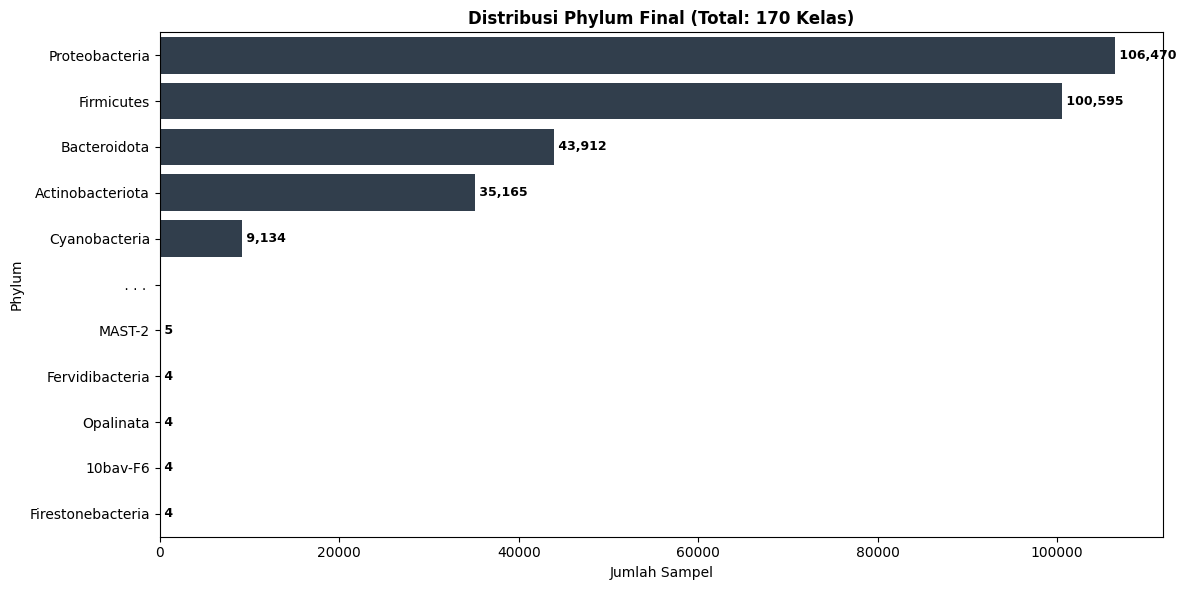


Data final tersimpan di 'processed_data/data_siap_ekstraksi.pkl'.


In [10]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("EKSEKUSI REGROUPING & VISUALISASI FINAL...")


df_imbalance['Phylum_Final'] = df_imbalance['Phylum'].replace(target_labels, 'Others')

final_counts = df_imbalance['Phylum_Final'].value_counts()
n_classes_final = len(final_counts)
others_count = final_counts.get('Others', 0)


print(f"\n[1] LAPORAN PERUBAHAN STRUKTUR DATA:")
print(f"   - Total Kelas Awal       : {n_classes} Phylum")
print(f"   - Total Kelas Akhir      : {n_classes_final} Phylum")
print(f"   - Pengurangan Kelas      : {n_classes - n_classes_final} kelas")
print(f"   - Total Sampel 'Others'  : {others_count:,} sampel")


print("\n[2] TABEL DISTRIBUSI FINAL:")

top5_f = final_counts.head(5).reset_index()
top5_f.columns = ['Phylum', 'Jumlah']
top5_f['Kategori'] = 'TOP 5 (Dominan)'

bot5_f = final_counts.tail(5).reset_index()
bot5_f.columns = ['Phylum', 'Jumlah']
bot5_f['Kategori'] = 'BOTTOM 5 (Terkecil)'

df_show = pd.concat([top5_f, bot5_f], ignore_index=True)

display(df_show.style.background_gradient(subset='Jumlah', cmap='Greens'))


print("\n[VISUALISASI] DISTRIBUSI PHYLUM (FINAL)")

plot_data = []

for i in range(min(5, len(final_counts))):
    idx = final_counts.index[i]
    val = final_counts.iloc[i]
    plot_data.append({'Phylum': idx, 'Jumlah': val, 'Type': 'Data'})

total_rows = len(final_counts)

if total_rows > 10:
    plot_data.append({'Phylum': ' . . . ', 'Jumlah': 0, 'Type': 'Spacer'})

for i in range(max(total_rows - 5, 5), total_rows):
    idx = final_counts.index[i]
    val = final_counts.iloc[i]
    plot_data.append({'Phylum': idx, 'Jumlah': val, 'Type': 'Data'})

df_plot = pd.DataFrame(plot_data)

plt.figure(figsize=(12, 6))

custom_colors = ['#2c3e50' if t == 'Data' else 'white' for t in df_plot['Type']]

ax = sns.barplot(
    data=df_plot,
    x='Jumlah',
    y='Phylum',
    hue='Phylum',
    palette=custom_colors,
    legend=False
)

plt.title(f'Distribusi Phylum Final (Total: {n_classes_final} Kelas)', fontweight='bold')
plt.xlabel('Jumlah Sampel')
plt.ylabel('Phylum')

for i, (val, name) in enumerate(zip(df_plot['Jumlah'], df_plot['Phylum'])):
    if val > 0:
        ax.text(val, i, f" {val:,}", va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


os.makedirs('processed_data', exist_ok=True)
df_imbalance.to_pickle('processed_data/data_siap_ekstraksi.pkl')

print("\nData final tersimpan di 'processed_data/data_siap_ekstraksi.pkl'.")

# 11. Ekstraksi Fitur k-mer dan Encoding Label

Pada tahap ini dilakukan transformasi sekuens DNA menjadi representasi 
numerik menggunakan metode k-mer. Setiap sekuens dipecah menjadi 
fragmen sepanjang k (k = 6 / hexamer), kemudian dihitung frekuensinya 
menggunakan CountVectorizer.

Label kelas Phylum yang telah diregrouping selanjutnya diubah menjadi 
format numerik menggunakan LabelEncoder untuk keperluan pemodelan.

In [11]:

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

print("MEMULAI EKSTRAKSI FITUR K-MER...")


try:
    df_final = pd.read_pickle('processed_data/data_siap_ekstraksi.pkl')
    print(f"   -> Data dimuat: {len(df_final):,} sampel.")
except FileNotFoundError:
    print("   [ERROR] File checkpoint tidak ditemukan.")


K_SIZE = 6 
print(f"   -> Mengekstrak fitur {K_SIZE}-mer (Hexamer)...")


vectorizer = CountVectorizer(
    analyzer='char',
    ngram_range=(K_SIZE, K_SIZE)
)

X = vectorizer.fit_transform(df_final['Sequence'])
feature_names = vectorizer.get_feature_names_out()


print("   -> Melakukan encoding label Phylum...")

le = LabelEncoder()
y = le.fit_transform(df_final['Phylum_Final'])


print("EKSTRAKSI SELESAI.")
print(f"   - Jumlah Sampel     : {X.shape[0]:,}")
print(f"   - Jumlah Fitur      : {X.shape[1]:,} k-mer")
print(f"   - Jumlah Kelas      : {len(le.classes_)} kelas")
print(f"   - Dimensi Matriks X : {X.shape[0]:,} x {X.shape[1]:,}")

MEMULAI EKSTRAKSI FITUR K-MER...


   -> Data dimuat: 398,508 sampel.
   -> Mengekstrak fitur 6-mer (Hexamer)...


   -> Melakukan encoding label Phylum...
EKSTRAKSI SELESAI.
   - Jumlah Sampel     : 398,508
   - Jumlah Fitur      : 4,096 k-mer
   - Jumlah Kelas      : 170 kelas
   - Dimensi Matriks X : 398,508 x 4,096


# 12. Analisis Karakteristik Fitur k-mer

Setelah proses ekstraksi fitur, dilakukan analisis terhadap struktur 
matriks k-mer untuk memahami karakteristik representasi data.

Visualisasi dilakukan untuk:
1. Mengamati tingkat sparsity (kekosongan) matriks fitur.
2. Mengidentifikasi 15 motif k-mer yang paling dominan muncul 
   dalam seluruh dataset.

MEMBUAT VISUALISASI SPARSITY (SKALA PENUH 4096)...


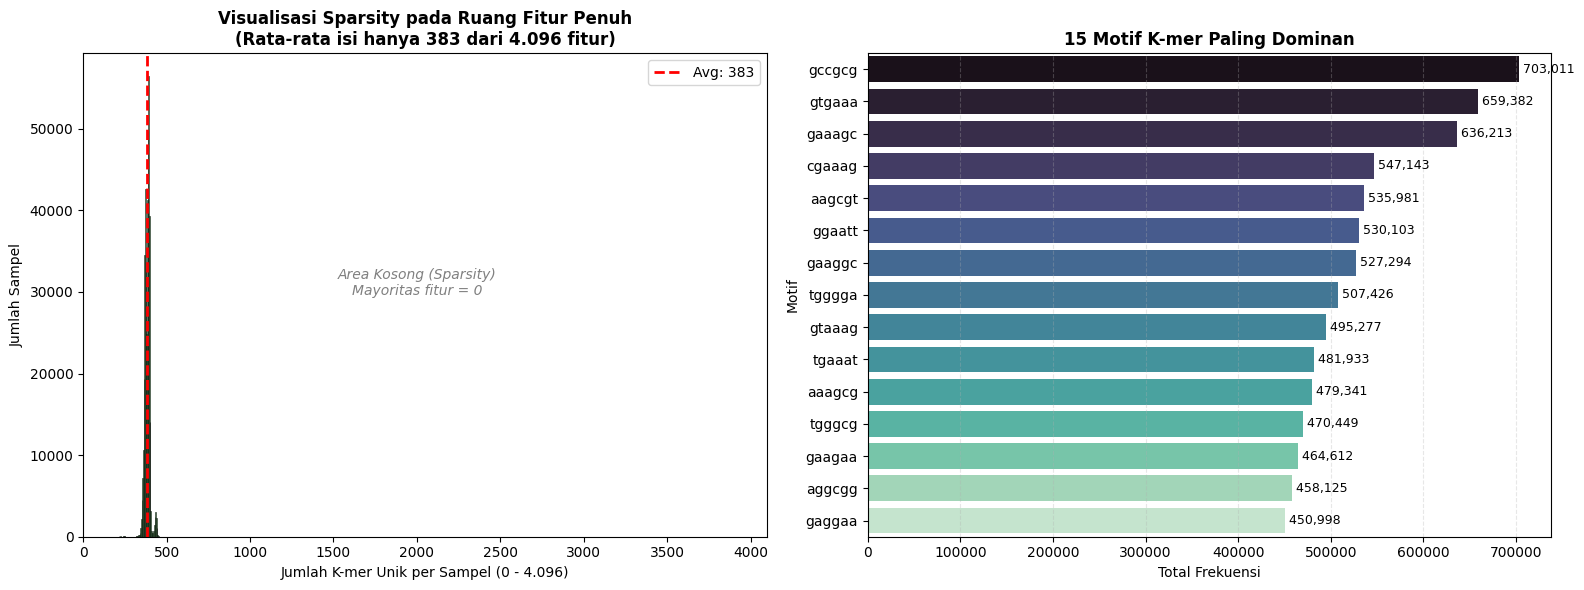

In [12]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix

print("MEMBUAT VISUALISASI SPARSITY (SKALA PENUH 4096)...")


non_zero_per_sample = X.getnnz(axis=1)

mean_val = np.mean(non_zero_per_sample)

total_cells = X.shape[0] * X.shape[1]
total_non_zero = X.nnz
sparsity_percent = 100 - (total_non_zero / total_cells * 100)

sum_kmers = np.array(X.sum(axis=0)).flatten()
kmer_counts = list(zip(feature_names, sum_kmers))
top_kmers = sorted(kmer_counts, key=lambda x: x[1], reverse=True)[:15]
df_top = pd.DataFrame(top_kmers, columns=['Motif', 'Count'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(non_zero_per_sample, bins=100, color='#4CAF50', kde=False, ax=axes[0])
axes[0].set_xlim(0, 4096)

axes[0].set_title(
    f'Visualisasi Sparsity pada Ruang Fitur Penuh\n'
    f'(Rata-rata isi hanya {int(mean_val)} dari 4.096 fitur)',
    fontweight='bold'
)

axes[0].set_xlabel('Jumlah K-mer Unik per Sampel (0 - 4.096)')
axes[0].set_ylabel('Jumlah Sampel')

axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=2,
                label=f'Avg: {int(mean_val)}')
axes[0].legend()

axes[0].text(
    2000,
    axes[0].get_ylim()[1]*0.5,
    'Area Kosong (Sparsity)\nMayoritas fitur = 0',
    color='gray',
    ha='center',
    fontstyle='italic'
)

sns.barplot(
    data=df_top,
    x='Count',
    y='Motif',
    hue='Motif',
    palette='mako',
    ax=axes[1],
    legend=False
)

axes[1].set_title('15 Motif K-mer Paling Dominan', fontweight='bold')
axes[1].set_xlabel('Total Frekuensi')
axes[1].set_ylabel('Motif')
axes[1].grid(axis='x', linestyle='--', alpha=0.3)

for i, v in enumerate(df_top['Count']):
    axes[1].text(v, i, f" {v:,}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 13. PENYIMPANAN HASIL EKSTRAKSI FITUR
Tujuan:
1. Menyimpan matriks fitur k-mer (X)
2. Menyimpan label terenkripsi (y)
3. Menyimpan vectorizer & label encoder

In [13]:

import joblib
import os

print("[PENYIMPANAN] MENYIMPAN OBJECT DATA...")



output_dir = 'processed_data'
os.makedirs(output_dir, exist_ok=True)


joblib.dump(X, f'{output_dir}/X_kmer.pkl')
joblib.dump(y, f'{output_dir}/y_encoded.pkl')
joblib.dump(vectorizer, f'{output_dir}/vectorizer.pkl')
joblib.dump(le, f'{output_dir}/label_encoder.pkl')


print(f"Berhasil disimpan di '{output_dir}/'.")

[PENYIMPANAN] MENYIMPAN OBJECT DATA...


Berhasil disimpan di 'processed_data/'.


# 14. PEMBAGIAN DATA (TRAIN-TEST SPLIT 80:20)
Tujuan:
1. Membagi data menjadi 80% data latih dan 20% data uji
2. Menggunakan stratified split untuk menjaga keseimbangan kelas
3. Menyiapkan data untuk proses training model

In [14]:

from sklearn.model_selection import train_test_split
import joblib
import pandas as pd
import numpy as np

print("MEMULAI PEMBAGIAN DATA (SPLITTING)...")


try:
    X = joblib.load('processed_data/X_kmer.pkl')
    y = joblib.load('processed_data/y_encoded.pkl')
    le = joblib.load('processed_data/label_encoder.pkl')
    print("   -> Data berhasil dimuat.")
except FileNotFoundError:
    print("   [ERROR] File data tidak ditemukan. Jalankan tahap ekstraksi dulu.")



X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



print(f"\nPEMBAGIAN SELESAI (Rasio 80:20)")
print(f"   - Data Latih (Train) : {X_train.shape[0]:,} sampel")
print(f"   - Data Uji (Test)    : {X_test.shape[0]:,} sampel")
print(f"   - Total Fitur        : {X_train.shape[1]:,} k-mers")


MEMULAI PEMBAGIAN DATA (SPLITTING)...


   -> Data berhasil dimuat.



PEMBAGIAN SELESAI (Rasio 80:20)
   - Data Latih (Train) : 318,806 sampel
   - Data Uji (Test)    : 79,702 sampel
   - Total Fitur        : 4,096 k-mers


# 15. VALIDASI DISTRIBUSI KELAS SETELAH SPLITTING
Tujuan:
1. Memastikan distribusi kelas tetap seimbang setelah stratified split
2. Membandingkan proporsi Train vs Test
3. Menyimpan hasil data latih dan data uji

In [ ]:

import pandas as pd
import numpy as np
import joblib

print("VALIDASI DISTRIBUSI KELAS...")



train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

total_train = len(y_train)
total_test = len(y_test)

df_comparison = pd.DataFrame({
    'Phylum': le.inverse_transform(train_counts.index),
    'Train (Jml)': train_counts.values,
    'Test (Jml)': test_counts.values,
    'Train (%)': (train_counts.values / total_train) * 100,
    'Test (%)': (test_counts.values / total_test) * 100
})

df_comparison['Selisih (%)'] = abs(
    df_comparison['Train (%)'] - df_comparison['Test (%)']
)

df_sorted = df_comparison.sort_values(
    'Train (Jml)', ascending=False
).reset_index(drop=True)



print(f"\n[RINGKASAN DATASET]")
print(f"   - Total Data Latih (Train) : {total_train:,} sampel")
print(f"   - Total Data Uji (Test)    : {total_test:,} sampel")
print(f"   - Total Kelas (Phylum)     : {len(df_sorted)} kelas")

print("\n[TABEL RINCIAN PRESISI TINGGI]")

pd.set_option('display.max_rows', None)

def fmt_precision(x):
    if x == 0:
        return "0"
    return "{:.10f}".format(x).rstrip('0').rstrip('.')

display(
    df_sorted.style
    .format({
        'Train (Jml)': '{:,}',
        'Test (Jml)': '{:,}',
        'Train (%)': fmt_precision,
        'Test (%)': fmt_precision,
        'Selisih (%)': fmt_precision
    })
    .background_gradient(
        subset=['Selisih (%)'],
        cmap='Reds',
        vmin=0,
        vmax=0.01
    )
    .bar(
        subset=['Train (Jml)'],
        color='#5fba7d'
    )
)

pd.reset_option('display.max_rows')



print("\n[PENYIMPANAN] MENYIMPAN DATA LATIH & UJI...")

joblib.dump(X_train, 'processed_data/X_train.pkl')
joblib.dump(X_test, 'processed_data/X_test.pkl')
joblib.dump(y_train, 'processed_data/y_train.pkl')
joblib.dump(y_test, 'processed_data/y_test.pkl')

print("Data split tersimpan")

# 16. Pelatihan Model Reduksi Dimensi (IPCA)
Melatih model Incremental PCA pada data latih secara bertahap (*batch processing*) untuk mempelajari struktur variansi data. Model ini akan menjadi acuan untuk iterasi CEV selanjutnya.

In [ ]:
import numpy as np
import pandas as pd
import joblib
import time
from sklearn.decomposition import IncrementalPCA

print("MELATIH MODEL IPCA...")

try:
    X_train = joblib.load('processed_data/X_train.pkl')
    print(f"   -> Data Latih Dimuat: {X_train.shape[0]:,} sampel x {X_train.shape[1]:,} fitur.")
except FileNotFoundError:
    print("   [ERROR] Data tidak ditemukan.")

BATCH_SIZE = 2048
MAX_COMPONENTS = 2048

ipca = IncrementalPCA(n_components=MAX_COMPONENTS, batch_size=BATCH_SIZE)

print(f"   -> Sedang fitting IPCA (Batch Size: {BATCH_SIZE})...")

def batch_generator(X_sparse, batch_size):
    n_samples = X_sparse.shape[0]
    for i in range(0, n_samples, batch_size):
        yield X_sparse[i : i + batch_size].toarray()

batch_count = 0
total_batches = int(np.ceil(X_train.shape[0] / BATCH_SIZE))
start_global = time.time()

for batch in batch_generator(X_train, BATCH_SIZE):
    t_batch_start = time.time()
    ipca.partial_fit(batch) 
    duration = time.time() - t_batch_start
    batch_count += 1
    elapsed = time.time() - start_global
    print(f"      - [Batch {batch_count}/{total_batches}] Durasi: {duration:.2f}s | Total: {elapsed:.1f}s ...", end='\r')

print(f"\n   -> Fitting selesai dalam {time.time() - start_global:.2f} detik.")

print("   -> Menghitung variansi kumulatif...", end=" ")
cumulative_variance = np.cumsum(ipca.explained_variance_ratio_)
print("Selesai.")

joblib.dump(ipca, 'processed_data/ipca_master_model.pkl')
joblib.dump(cumulative_variance, 'processed_data/cumulative_variance.pkl')
print("Model IPCA Utama berhasil disimpan.")

# 17. Iterasi CEV dan Klasifikasi
Melakukan eksperimen pada variasi CEV (0.50 - 0.95).

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time
import joblib
import numpy as np

print("ITERASI CEV DENGAN METRIK LENGKAP...")

X_train = joblib.load('processed_data/X_train.pkl')
X_test = joblib.load('processed_data/X_test.pkl')
y_train = joblib.load('processed_data/y_train.pkl')
y_test = joblib.load('processed_data/y_test.pkl')
ipca = joblib.load('processed_data/ipca_master_model.pkl')
cumulative_variance = joblib.load('processed_data/cumulative_variance.pkl')

cev_targets = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]
results = []

best_f1 = -1
best_model_data = {} 

print(f"\n{'Target':<6} | {'k':<5} | {'Akurasi':<8} | {'Presisi':<8} | {'Recall':<8} | {'F1-Score':<8} | {'AUC':<8} | {'Conf.':<6} | {'Waktu':<8}")
print("-" * 110)

def transform_manual(X_sparse, mean, components, batch_size=2048):
    X_transformed = []
    for i in range(0, X_sparse.shape[0], batch_size):
        batch = X_sparse[i : i + batch_size].toarray()
        batch_centered = batch - mean
        batch_proj = np.dot(batch_centered, components.T)
        X_transformed.append(batch_proj)
    return np.vstack(X_transformed)

for target_cev in cev_targets:
    iter_start = time.time()
    k = np.argmax(cumulative_variance >= target_cev) + 1
    components_k = ipca.components_[:k]
    mean_k = ipca.mean_
    X_train_red = transform_manual(X_train, mean_k, components_k)
    X_test_red  = transform_manual(X_test, mean_k, components_k)
    gnb = GaussianNB()
    gnb.fit(X_train_red, y_train)
    y_pred = gnb.predict(X_test_red)
    y_prob = gnb.predict_proba(X_test_red) 
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    try:
        auc_score = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
    except:
        auc_score = 0.0 
    avg_confidence = np.mean(np.max(y_prob, axis=1))
    total_time = time.time() - iter_start
    results.append({
        'Target CEV': target_cev,
        'Jml Komponen': k,
        'Akurasi': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC': auc_score,
        'Avg Confidence': avg_confidence,
        'Waktu (s)': total_time
    })
    print(f"{target_cev:<6} | {k:<5} | {acc:.4f}   | {prec:.4f}   | {rec:.4f}   | {f1:.4f}   | {auc_score:.4f}   | {avg_confidence:.2f}   | {total_time:.1f}s")
    if f1 > best_f1:
        best_f1 = f1
        best_model_data = {
            'cev': target_cev,
            'k': k,
            'y_test': y_test,
            'y_pred': y_pred,
            'y_prob': y_prob,
            'model': gnb,
            'X_test_red': X_test_red
        }

joblib.dump(best_model_data, 'processed_data/best_model_viz_data.pkl')
joblib.dump(results, 'processed_data/all_results_metrics.pkl')

print("\n Iterasi selesai. Data model terbaik disimpan untuk visualisasi.")

# 18: ANALISIS REDUKSI DIMENSI & EVALUASI CEV

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from math import pi
from scipy.interpolate import PchipInterpolator

target_cev = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
k_components = [60, 118, 234, 474, 1030, 1622]
accuracy = [0.9609, 0.9689, 0.9655, 0.9409, 0.8722, 0.8112]
f1_score = [0.9634, 0.9705, 0.9678, 0.9474, 0.8844, 0.8298]
auc_roc = [0.9994, 0.9994, 0.9989, 0.9920, 0.9624, 0.9311]
confidence = [0.99, 0.99, 0.99, 0.99, 0.99, 0.99]
waktu = [52.9, 68.0, 97.4, 158.5, 297.4, 447.2]
precision = [0.9687, 0.9743, 0.9734, 0.9618, 0.9139, 0.8721]
recall = [0.9609, 0.9689, 0.9655, 0.9409, 0.8722, 0.8112]

plt.rcParams['font.family'] = 'sans-serif'


x_smooth = np.linspace(0, 2000, 500)
k_fit = [0] + k_components
cev_fit = [0.05] + target_cev 
interpolator = PchipInterpolator(k_fit, cev_fit)
y_smooth = interpolator(x_smooth)

fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(x_smooth, y_smooth, color='#1f77b4', linewidth=2.5, label='Cumulative Variance')
ax1.fill_between(x_smooth, y_smooth, color='#1f77b4', alpha=0.15)

ax1.plot(k_components, target_cev, 'ro', markersize=6, label='Target Points')

for k, cev in zip(k_components, target_cev):
    ax1.annotate(f"{cev}", 
                 xy=(k, cev), 
                 xytext=(30, -20), 
                 textcoords='offset points',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.5),
                 arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2", color="black"),
                 fontsize=10, fontweight='bold', color='black')

ax1.set_xlim(-100, 2100)
ax1.set_ylim(-0.05, 1.05)
ax1.set_xlabel('Jumlah Komponen Utama (Principal Components)', fontweight='bold')
ax1.set_ylabel('Proporsi Variansi Tertangkap', fontweight='bold')
ax1.legend(loc='lower right', frameon=True, edgecolor='black')
plt.tight_layout()
plt.show()


fig2, ax_left = plt.subplots(figsize=(10, 6))

line1 = ax_left.plot(target_cev, accuracy, marker='o', color='#1f77b4', linewidth=2, label='Akurasi')
line2 = ax_left.plot(target_cev, f1_score, marker='x', linestyle='--', color='#2ca02c', linewidth=2, label='Weighted F1-Score')
ax_left.set_xlabel('Target Cumulative Explained Variance (CEV)', fontweight='bold')
ax_left.set_ylabel('Skor Metrik (Akurasi & Weighted F1)', fontweight='bold')
ax_left.set_xticks(target_cev)

ax_right = ax_left.twinx()
line3 = ax_right.plot(target_cev, waktu, marker='s', color='#d62728', linewidth=2, label='Waktu (s)')
ax_right.set_ylabel('Waktu Komputasi (detik)', fontweight='bold', color='#d62728')
ax_right.tick_params(axis='y', labelcolor='#d62728')

lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax_left.legend(lines, labels, loc='center left', bbox_to_anchor=(0.02, 0.5), edgecolor='black')

plt.tight_layout()
plt.show()


fig3, ax_acc = plt.subplots(figsize=(10, 6))

ax_acc.plot(target_cev, accuracy, marker='o', color='#1f77b4', linewidth=2.5, label='Akurasi')
ax_acc.set_xlabel('Target CEV (Jumlah Komponen)', fontweight='bold', labelpad=15)
ax_acc.set_ylabel('Akurasi Klasifikasi', fontweight='bold', color='#1f77b4')
ax_acc.tick_params(axis='y', labelcolor='#1f77b4')
plt.xticks(target_cev, [f"{cev}\n(k={k})" for cev, k in zip(target_cev, k_components)])

ax_time = ax_acc.twinx()
ax_time.plot(target_cev, waktu, marker='s', linestyle='--', color='#d62728', linewidth=2.5, label='Waktu (s)')
ax_time.set_ylabel('Waktu Komputasi (detik)', fontweight='bold', color='#d62728')
ax_time.tick_params(axis='y', labelcolor='#d62728')

ax_acc.annotate('Titik Optimal (Sweet Spot)\nCEV 0.6 | k=118', 
                xy=(0.6, 0.9689), 
                xytext=(0.7, 0.89),
                bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", lw=1),
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-0.2", color="black", lw=1.5),
                fontsize=10, fontweight='bold', ha='center')

lines3 = ax_acc.get_lines() + ax_time.get_lines()
labels3 = [l.get_label() for l in lines3]
ax_acc.legend(lines3, labels3, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=2, edgecolor='black')
fig3.subplots_adjust(bottom=0.25)
plt.show()


fig4, ax_auc = plt.subplots(figsize=(10, 6))

ax_auc.plot(target_cev, auc_roc, marker='^', color='#8e44ad', linewidth=2, label='AUC')
ax_auc.plot(target_cev, accuracy, marker='o', color='#27ae60', linewidth=2, label='Akurasi')
ax_auc.plot(target_cev, confidence, linestyle='--', color='#e74c3c', linewidth=2.5, label='Confidence')

ax_auc.fill_between(target_cev, accuracy, confidence, color='#f5b7b1', alpha=0.2, label='Area Overconfidence')

ax_auc.set_ylim(0.70, 1.05)
ax_auc.set_xlabel('Target Cumulative Explained Variance (CEV)', fontweight='bold', labelpad=10)
ax_auc.set_ylabel('Skor Metrik (0.0 - 1.0)', fontweight='bold')
plt.xticks(target_cev, [f"{cev}\n(k={k})" for cev, k in zip(target_cev, k_components)])

ax_auc.annotate('AUC Mulai Menurun', xy=(0.8, 0.9920), xytext=(0.65, 1.03),
                arrowprops=dict(arrowstyle="->", color="black"), fontweight='bold')
ax_auc.annotate('Indikasi Overconfidence\n(Akurasi < Confidence)', xy=(0.95, 0.8112), xytext=(0.83, 0.76),
                arrowprops=dict(arrowstyle="->", color="black"), fontweight='bold')

ax_auc.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fancybox=True, shadow=True, edgecolor='black')
fig4.subplots_adjust(bottom=0.2)
plt.show()


data = {
    'Skenario': ['CEV 0.5', 'CEV 0.6', 'CEV 0.7', 'CEV 0.8', 'CEV 0.9', 'CEV 0.95'],
    'Akurasi': accuracy,
    'Weighted\nF1-Score': f1_score, 
    'AUC': auc_roc,
    'Precision': precision,
    'Recall': recall,
    'Confidence': confidence
}
df = pd.DataFrame(data)

categories = ['Akurasi', 'Weighted\nF1-Score', 'AUC', 'Precision', 'Recall', 'Confidence']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

radar_colors = ['#4c92c3', '#e24a4f', '#59a14f', '#b07aa1', '#fd9e49', '#e88cbc']
radar_markers = ['o', 's', '^', 'D', 'v', 'P']

fig_radar = plt.figure(figsize=(8, 8))
ax_radar = fig_radar.add_subplot(111, polar=True)
ax_radar.set_theta_offset(pi / 2)
ax_radar.set_theta_direction(-1)

plt.xticks(angles[:-1], categories, fontweight='bold', fontsize=9)
plt.ylim(0.78, 1.01)

for i, row in df.iterrows():
    values = row[categories].values.tolist()
    values += values[:1]
    ax_radar.plot(angles, values, linewidth=2, color=radar_colors[i], marker=radar_markers[i], markersize=7, label=row['Skenario'])

ax_radar.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()
plt.show()


fig_table, ax_table = plt.subplots(figsize=(10, 3))
ax_table.axis('off')
table_data = [[f"{x:.4f}" if isinstance(x, float) else x for x in row] for row in df.values]
table = ax_table.table(cellText=table_data, colLabels=df.columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.1, 2.5) 
plt.tight_layout()
plt.show()


fig_gabung = plt.figure(figsize=(16, 7))

ax_gabung1 = fig_gabung.add_subplot(121, polar=True)
ax_gabung1.set_theta_offset(pi / 2)
ax_gabung1.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, fontweight='bold', fontsize=9)
plt.ylim(0.78, 1.01)

for i, row in df.iterrows():
    values = row[categories].values.tolist()
    values += values[:1]
    ax_gabung1.plot(angles, values, linewidth=2, color=radar_colors[i], marker=radar_markers[i], markersize=7, label=row['Skenario'])
ax_gabung1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

ax_gabung2 = fig_gabung.add_subplot(122)
ax_gabung2.axis('off')
table_gabung = ax_gabung2.table(cellText=table_data, colLabels=df.columns, loc='center', cellLoc='center')
table_gabung.auto_set_font_size(False)
table_gabung.set_fontsize(10)
table_gabung.scale(1.15, 2.2) 

plt.tight_layout()
plt.show()

In [ ]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from IPython.display import display

print("MEMUAT DATA UNTUK ANALISIS REDUKSI DIMENSI BAB 4...")

output_dir = 'processed_data'
ipca = joblib.load(f'{output_dir}/ipca_master_model.pkl')
cum_var = joblib.load(f'{output_dir}/cumulative_variance.pkl')
best_data = joblib.load(f'{output_dir}/best_model_viz_data.pkl')
le = joblib.load(f'{output_dir}/label_encoder.pkl')

X_train_raw = joblib.load(f'{output_dir}/X_train.pkl') 
y_train = joblib.load(f'{output_dir}/y_train.pkl')
le_labels_train = le.inverse_transform(y_train)
n_rows_train = X_train_raw.shape[0]

try:
    vectorizer = joblib.load(f'{output_dir}/vectorizer.pkl')
    feature_names = vectorizer.get_feature_names_out()
except FileNotFoundError:
    feature_names = [f'Kmer_{i+1}' for i in range(ipca.components_.shape[1])]


def clear_nan_bg(val):
    if pd.isna(val):
        return 'background-color: transparent; color: inherit; text-align: center;'
    return ''

k_opt = best_data['k']
cev_opt = best_data['cev']

print(f"\n[BUKTI 1] NILAI EIGEN UNTUK {k_opt} KOMPONEN (CEV {cev_opt})")
print("="*80)

eigenvalues = ipca.explained_variance_[:k_opt]
var_ratio = ipca.explained_variance_ratio_[:k_opt] * 100
cum_var_pct = cum_var[:k_opt] * 100

df_eigen_full = pd.DataFrame({
    'Komponen': [f'PC{i+1}' for i in range(k_opt)],
    'Nilai Eigen': eigenvalues,
    'Variansi (%)': var_ratio,
    'Kumulatif (%)': cum_var_pct
})

df_top = df_eigen_full.head(3).copy()
df_bot = df_eigen_full.tail(3).copy()

df_mid = pd.DataFrame({
    'Komponen': ['...'],
    'Nilai Eigen': [np.nan],
    'Variansi (%)': [np.nan],
    'Kumulatif (%)': [np.nan]
}, index=['...'])

df_eigen_display = pd.concat([df_top, df_mid, df_bot])

styled_eigen = (df_eigen_display.style
    .format({
        'Nilai Eigen': '{:.4f}', 
        'Variansi (%)': '{:.4f}%', 
        'Kumulatif (%)': '{:.4f}%'
    }, na_rep="...")
    .background_gradient(subset=['Nilai Eigen'], cmap='Blues')
    .apply(lambda col: col.map(clear_nan_bg), subset=['Nilai Eigen', 'Variansi (%)', 'Kumulatif (%)'])
)

display(styled_eigen)


print("\n[BUKTI 2] MATRIKS VEKTOR EIGEN (BOBOT K-MER PADA MODEL IPCA)")
print("="*80)

eigenvectors = ipca.components_
target_pc = 1622
n_features = eigenvectors.shape[1]  

row_idx = [0, 1, 2, target_pc-3, target_pc-2, target_pc-1]
col_idx = [0, 1, 2, n_features-3, n_features-2, n_features-1]

matrix_eigen = eigenvectors[np.ix_(row_idx, col_idx)]

full_matrix_eigen = np.full((7, 7), np.nan)
full_matrix_eigen[:3, :3] = matrix_eigen[:3, :3]
full_matrix_eigen[:3, 4:] = matrix_eigen[:3, 3:]
full_matrix_eigen[4:, :3] = matrix_eigen[3:, :3]
full_matrix_eigen[4:, 4:] = matrix_eigen[3:, 3:]

row_labels = ['PC1', 'PC2', 'PC3', '...', f'PC{target_pc-2}', f'PC{target_pc-1}', f'PC{target_pc}']
col_labels = [feature_names[i] for i in col_idx[:3]] + ['...'] + [feature_names[i] for i in col_idx[3:]]

df_eigenvectors = pd.DataFrame(full_matrix_eigen, columns=col_labels, index=row_labels)

styled_eigenvectors = (df_eigenvectors.style
    .format("{:.5f}", na_rep="...")
    .background_gradient(cmap='PRGn', axis=None)
    .apply(lambda col: col.map(clear_nan_bg))
)

display(styled_eigenvectors)


print("\n[BUKTI 3] MATRIKS KONTINU (HASIL TRANSFORMASI DATA LATIH)")
print("="*80)

n_cols_target = 1622 
idx_rows_train = [0, 1, 2, n_rows_train-3, n_rows_train-2, n_rows_train-1]
X_sample_raw = X_train_raw[idx_rows_train]

X_sample_pca = (X_sample_raw.toarray() - ipca.mean_) @ ipca.components_[:n_cols_target].T

matrix_display = X_sample_pca[:, [0, 1, 2, 1619, 1620, 1621]]

full_matrix_pca = np.full((7, 7), np.nan)
full_matrix_pca[:3, :3] = matrix_display[:3, :3]
full_matrix_pca[:3, 4:] = matrix_display[:3, 3:]
full_matrix_pca[4:, :3] = matrix_display[3:, :3]
full_matrix_pca[4:, 4:] = matrix_display[3:, 3:]

col_names = ['PC1', 'PC2', 'PC3', '...', 'PC1620', 'PC1621', 'PC1622']
row_names = ['Sampel_1', 'Sampel_2', 'Sampel_3', '...',  
             f'Sampel_{n_rows_train-2}', f'Sampel_{n_rows_train-1}', f'Sampel_{n_rows_train}']

df_matrix_pca = pd.DataFrame(full_matrix_pca, columns=col_names, index=row_names)

styled_matrix_pca = (df_matrix_pca.style
    .format("{:.4f}", na_rep="...")
    .background_gradient(cmap='coolwarm', axis=None)
    .apply(lambda col: col.map(clear_nan_bg))
)

display(styled_matrix_pca)


print("\n[BUKTI 4] DISTRIBUSI BOBOT VEKTOR EIGEN PADA 4.096 K-MER")
print("="*80)

pc1_weights = eigenvectors[0, :]
pc2_weights = eigenvectors[1, :]

def plot_gaussian_proof(data, ax_obj, title, color_hist, color_line):
    sns.histplot(data, bins=60, stat='density', alpha=0.5, color=color_hist, ax=ax_obj)
    mu, std = stats.norm.fit(data)
    xmin, xmax = ax_obj.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, mu, std)
    ax_obj.plot(x, p, linewidth=2.5, color=color_line, label=f'Gaussian ($\\mu={mu:.2f}$)')
    ax_obj.set_title(title, fontweight='bold')
    ax_obj.legend()

fig1, ax1 = plt.subplots(1, 2, figsize=(16, 5))
plot_gaussian_proof(pc1_weights, ax1[0], "Distribusi Bobot k-mer pada PC1", '#2ecc71', '#27ae60')
plot_gaussian_proof(pc2_weights, ax1[1], "Distribusi Bobot k-mer pada PC2", '#2ecc71', '#27ae60')
plt.suptitle("Karakteristik Model: Sebaran Nilai Bobot Vektor Eigen terhadap 4.096 Fitur Asli", fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


print("\n[BUKTI 5] DISTRIBUSI HASIL TRANSFORMASI PADA 318.806 DATA LATIH")
print("="*80)
print("Memproses transformasi seluruh data latih secara bertahap (batch)...")

batch_size = 4096
pcs_train = []

for i in range(0, n_rows_train, batch_size):
    batch = X_train_raw[i:i+batch_size].toarray()
    batch_centered = batch - ipca.mean_
    batch_pcs = batch_centered @ ipca.components_[:2].T 
    pcs_train.append(batch_pcs)

X_train_red_2d = np.vstack(pcs_train)
pc1_train = X_train_red_2d[:, 0]
pc2_train = X_train_red_2d[:, 1]

fig2, ax2 = plt.subplots(1, 2, figsize=(16, 5))
plot_gaussian_proof(pc1_train, ax2[0], "Distribusi Sampel Latih pada PC1", '#3498db', '#e74c3c')
plot_gaussian_proof(pc2_train, ax2[1], "Distribusi Sampel Latih pada PC2", '#3498db', '#e74c3c')
plt.suptitle("Karakteristik Data: Sebaran Koordinat 318.806 Sampel Latih (Syarat Naïve Bayes)", fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [ ]:
import joblib
import pandas as pd
import numpy as np

try:
    X_train = joblib.load('processed_data/X_train.pkl')
    vectorizer = joblib.load('processed_data/vectorizer.pkl')
    feature_names = vectorizer.get_feature_names_out()
    print("Berhasil memuat data.")
except:
    print("File tidak ditemukan. Pastikan file ada di folder 'processed_data/'")

sample_matrix = X_train[:10, :10].toarray()

df_kmer = pd.DataFrame(
    sample_matrix, 
    columns=feature_names[:10], 
    index=[f'Sampel_{i+1}' for i in range(10)]
)

print("\n=== CUPLIKAN MATRIKS K-MER (DATA ASLI) ===")
display(df_kmer)

df_kmer.to_csv('cuplikan_matriks_kmer.csv')
print("\nFile 'cuplikan_matriks_kmer.csv' telah berhasil disimpan.")

In [ ]:
import joblib
import pandas as pd
import numpy as np
from IPython.display import display

def clear_nan_bg(val):
    if pd.isna(val):
        return 'background-color: transparent; color: inherit; text-align: center;'
    return ''

try:
    X_train = joblib.load('processed_data/X_train.pkl')
    vectorizer = joblib.load('processed_data/vectorizer.pkl')
    feature_names = vectorizer.get_feature_names_out()
    print("Berhasil memuat data.")
except:
    print("File tidak ditemukan. Pastikan file ada di folder 'processed_data/'")

n_features = X_train.shape[1]

col_idx_awal = [0, 1, 2]
col_idx_akhir = [n_features-3, n_features-2, n_features-1]
col_idx_gabungan = col_idx_awal + col_idx_akhir

sample_matrix_asli = X_train[:10, col_idx_gabungan].toarray()

matrix_display = np.full((10, 7), np.nan)
matrix_display[:, :3] = sample_matrix_asli[:, :3] 
matrix_display[:, 4:] = sample_matrix_asli[:, 3:] 

col_labels = (
    [feature_names[i] for i in col_idx_awal] + 
    ['...'] + 
    [feature_names[i] for i in col_idx_akhir]
)

df_kmer = pd.DataFrame(
    matrix_display, 
    columns=col_labels, 
    index=[f'Sampel_{i+1}' for i in range(10)]
)

print("\n=== CUPLIKAN MATRIKS K-MER (3 FITUR AWAL ... 3 FITUR AKHIR) ===")
styled_df = (df_kmer.style
    .format("{:.0f}", na_rep="...")
    .background_gradient(cmap='Greens', axis=None)
    .apply(lambda col: col.map(clear_nan_bg))
)
display(styled_df)

df_asli_export = pd.DataFrame(
    sample_matrix_asli, 
    columns=[feature_names[i] for i in col_idx_gabungan], 
    index=[f'Sampel_{i+1}' for i in range(10)]
)
df_asli_export.to_csv('cuplikan_matriks_kmer_ujung.csv')
print("\nFile 'cuplikan_matriks_kmer_ujung.csv' telah berhasil disimpan.")

In [ ]:
import joblib
import pandas as pd
import numpy as np
from IPython.display import display

print("MEMUAT MATRIKS K-MER (X_train) DAN VECTORIZER...")

try:
    X_train = joblib.load('processed_data/X_train.pkl')
    vectorizer = joblib.load('processed_data/vectorizer.pkl')
    feature_names = vectorizer.get_feature_names_out()
    print("Berhasil memuat data.")
    kmer_sums = X_train.sum(axis=0)
    kmer_sums_1d = np.asarray(kmer_sums).flatten() 
    top_10_indices = np.argsort(kmer_sums_1d)[::-1][:10]
    top_10_kmers = feature_names[top_10_indices]
    top_10_freqs = kmer_sums_1d[top_10_indices]
    sample_matrix = X_train[:10, top_10_indices].toarray()
    df_kmer = pd.DataFrame(
        sample_matrix, 
        columns=top_10_kmers, 
        index=[f'Sampel_{i+1}' for i in range(10)]
    )
    print("\n=== 10 K-MER DENGAN TOTAL KEMUNCULAN TERTINGGI ===")
    for kmer, freq in zip(top_10_kmers, top_10_freqs):
        print(f"- {kmer}: {freq:,.0f} kali")
    print("\n=== CUPLIKAN MATRIKS K-MER (10 Sampel Awal x 10 K-mer Teratas) ===")
    display(df_kmer)
    df_kmer.to_csv('cuplikan_matriks_kmer_teratas.csv')
    print("\nFile 'cuplikan_matriks_kmer_teratas.csv' telah berhasil disimpan.")

except Exception as e:
    print(f"Terjadi kesalahan: {e}")
    print("Pastikan file ada di folder 'processed_data/'")

In [ ]:
import pandas as pd
import numpy as np
import joblib

print("VALIDASI DISTRIBUSI KELAS...")


train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

total_train = len(y_train)
total_test = len(y_test)

df_comparison = pd.DataFrame({
    'Phylum': le.inverse_transform(train_counts.index),
    'Train (Jml)': train_counts.values,
    'Test (Jml)': test_counts.values,
    'Train (%)': (train_counts.values / total_train) * 100,
    'Test (%)': (test_counts.values / total_test) * 100
})

df_comparison['Selisih (%)'] = abs(
    df_comparison['Train (%)'] - df_comparison['Test (%)']
)

df_sorted = df_comparison.sort_values(
    'Train (Jml)', ascending=False
).reset_index(drop=True)



print(f"\n[RINGKASAN DATASET]")
print(f"   - Total Data Latih (Train) : {total_train:,} sampel")
print(f"   - Total Data Uji (Test)    : {total_test:,} sampel")
print(f"   - Total Kelas (Phylum)     : {len(df_sorted)} kelas")



top_rows = df_sorted.head(3)
bottom_rows = df_sorted.tail(3)

separator = pd.DataFrame({
    'Phylum': ['...'],
    'Train (Jml)': ['...'],
    'Test (Jml)': ['...'],
    'Train (%)': ['...'],
    'Test (%)': ['...'],
    'Selisih (%)': ['...']
})

df_display = pd.concat([top_rows, separator, bottom_rows]).reset_index(drop=True)



def fmt_precision(x):
    if isinstance(x, str):
        return x
    if x == 0:
        return "0"
    return "{:.10f}".format(x).rstrip('0').rstrip('.')


print("\n[TABEL DISTRIBUSI KELAS - RINGKASAN]")
display(
    df_display.style.format({
        'Train (Jml)': lambda x: f"{x:,}" if isinstance(x,(int,float)) else x,
        'Test (Jml)': lambda x: f"{x:,}" if isinstance(x,(int,float)) else x,
        'Train (%)': fmt_precision,
        'Test (%)': fmt_precision,
        'Selisih (%)': fmt_precision
    })
)



print("\n[PENYIMPANAN] MENYIMPAN DATA LATIH & UJI...")

joblib.dump(X_train, 'processed_data/X_train.pkl')
joblib.dump(X_test, 'processed_data/X_test.pkl')
joblib.dump(y_train, 'processed_data/y_train.pkl')
joblib.dump(y_test, 'processed_data/y_test.pkl')

print("Data split tersimpan")

In [ ]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from IPython.display import display

print("MEMUAT DATA UNTUK ANALISIS REDUKSI DIMENSI BAB 4...")

output_dir = 'processed_data'
ipca = joblib.load(f'{output_dir}/ipca_master_model.pkl')
cum_var = joblib.load(f'{output_dir}/cumulative_variance.pkl')
best_data = joblib.load(f'{output_dir}/best_model_viz_data.pkl')
le = joblib.load(f'{output_dir}/label_encoder.pkl')

X_train_raw = joblib.load(f'{output_dir}/X_train.pkl') 
y_train = joblib.load(f'{output_dir}/y_train.pkl')
le_labels_train = le.inverse_transform(y_train)
n_rows_train = X_train_raw.shape[0]

try:
    vectorizer = joblib.load(f'{output_dir}/vectorizer.pkl')
    feature_names = vectorizer.get_feature_names_out()
except FileNotFoundError:
    feature_names = [f'Kmer_{i+1}' for i in range(ipca.components_.shape[1])]


target_cev = 0.95
k_opt = np.argmax(cum_var >= target_cev) + 1 
cev_opt = cum_var[k_opt - 1]

print(f"\n[BUKTI 1] NILAI EIGEN UNTUK {k_opt} KOMPONEN (CEV {cev_opt*100:.2f}%)")
print("="*80)

eigenvalues = ipca.explained_variance_[:k_opt]
var_ratio = ipca.explained_variance_ratio_[:k_opt] * 100
cum_var_pct = cum_var[:k_opt] * 100

df_eigen = pd.DataFrame({
    'Komponen': [f'PC{i+1}' for i in range(k_opt)],
    'Nilai Eigen': eigenvalues,
    'Variansi (%)': var_ratio,
    'Kumulatif (%)': cum_var_pct
})

styled_eigen = (df_eigen.style
    .format({
        'Nilai Eigen': '{:.4f}', 
        'Variansi (%)': '{:.4f}%', 
        'Kumulatif (%)': '{:.4f}%'
    })
    .background_gradient(subset=['Nilai Eigen'], cmap='Blues')
)
display(styled_eigen)